# Are Nonprofits Ready To Use AI For Outreach To Increase Donor Retention?

In [19]:
import pandas as pd
import matplotlib.pyplot as pyplot
import numpy as np
import seaborn as sns
import scipy as sp

In [20]:
normalized_df = pd.read_csv('../ai_survey_normalized_clustering_data.csv')
survey_df = pd.read_csv('../ai_survey_results_2024_n=930.csv')

In [21]:
normalized_df.head()

,Unnamed: 0,nonprofit,org_years,regionality,org_small_med_large,global_north_south_int,collects_data,tech_person,merl_person,cloud_storage,...,[W] Generat,[W] Interpret,[W] Organi,[W] Predict,[W] Translat,[W] Other,[W] We don't know yet!,cluster3,cluster2,ai_want_2+
0,0,1.0,0.560000,0.25,1.0,0.0,1.0,0.0,0.0,1.0,...,0,0,1,1,0,0,0,1,1,1
1,1,1.0,0.046667,0.25,0.0,0.0,1.0,0.0,0.0,1.0,...,1,1,1,1,1,1,0,0,0,1
2,2,1.0,0.226667,0.25,0.0,0.0,1.0,1.0,0.0,1.0,...,0,1,0,0,1,0,0,-1,0,1
3,3,1.0,0.166667,0.50,0.0,0.0,1.0,1.0,1.0,1.0,...,0,1,1,1,0,0,0,1,1,1
4,4,1.0,0.053333,0.50,0.0,0.0,1.0,0.0,0.0,1.0,...,1,1,1,1,1,0,0,0,0,1


In [22]:
survey_df.head()

,Unnamed: 0,source,Start time,nonprofit,non_org_type,role,person_org_years,org_size,org_years,continent,...,global_north_south_int,org_size_int,hubs_rural_urban_int,af_region_int,india_rural_urban_int,collab_feasibility_raw,person_ai_comfort_raw,org_years_raw,person_org_years_raw,cluster3
0,0,The big one,2024-03-07 11:03:50,1.0,NaN,Fundraiser,0.066667,31-60,0.560000,North America,...,0.0,5.0,NaN,NaN,NaN,7.0,7.0,84.0,4.0,1
1,1,The big one,2024-03-07 11:03:03,1.0,NaN,Leader,0.116667,0-5,0.046667,North America,...,0.0,0.0,NaN,NaN,NaN,4.0,5.0,7.0,7.0,0
2,2,The big one,2024-03-07 11:05:30,1.0,NaN,Leader,0.016667,6-15,0.226667,North America,...,0.0,1.0,NaN,NaN,NaN,3.0,10.0,34.0,1.0,-1
3,3,The big one,2024-03-07 11:05:30,1.0,NaN,Comms,0.133333,6-15,0.166667,North America,...,0.0,1.0,NaN,NaN,NaN,8.0,10.0,25.0,8.0,1
4,4,The big one,2024-03-07 11:07:06,1.0,NaN,Leader,0.133333,0-5,0.053333,North America,...,0.0,0.0,NaN,NaN,NaN,4.0,0.0,8.0,8.0,0


## Step 0: Data Cleaning

In [23]:
# Drop non_org_type (96% null) and strip whitespace across all string columns
survey_df = survey_df.drop(columns=['non_org_type'])

for col in survey_df.select_dtypes(include='object').columns:
    survey_df[col] = survey_df[col].str.strip()

/var/folders/wj/f5mwndv501bc3llhjvlrdcz80000gn/T/ipykernel_34049/1013878781.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in survey_df.select_dtypes(include='object').columns:


In [24]:
import ast

LIST_COLS = ['ai_use', 'ai_want', 'ai_risk', 'data_kinds']

def parse_list_col(val):
    if pd.isna(val):
        return []
    # replace non-breaking spaces before parsing
    val = val.replace('\xa0', ' ')
    try:
        items = ast.literal_eval(val)
        return [s.strip() for s in items if isinstance(s, str) and s.strip()]
    except Exception:
        return [val.strip()] if val.strip() else []

for col in LIST_COLS:
    if col in survey_df.columns:
        survey_df[col] = survey_df[col].apply(parse_list_col)

In [25]:
# Drop rows where org_opentext is too short to be usable (< 5 chars)
survey_df = survey_df[
    survey_df['org_opentext'].isna() | (survey_df['org_opentext'].str.len() >= 5)
]

In [26]:
# Impute person_ai_comfort_raw from normalized person_ai_comfort (scale: 0–10)
mask = survey_df['person_ai_comfort_raw'].isna() & survey_df['person_ai_comfort'].notna()
survey_df.loc[mask, 'person_ai_comfort_raw'] = (survey_df.loc[mask, 'person_ai_comfort'] * 10).round()

In [27]:
# Fill missing region values with 'Unknown'
survey_df['continent'] = survey_df['continent'].fillna('Unknown')
survey_df['global_north_south'] = survey_df['global_north_south'].fillna('Unknown')

In [28]:
# Merge survey and normalized datasets on index
merged_df = survey_df.merge(
    normalized_df,
    left_index=True,
    right_index=True,
    suffixes=('', '_norm')
)

print(f"survey_df: {survey_df.shape}, normalized_df: {normalized_df.shape}, merged_df: {merged_df.shape}")

survey_df: (906, 47), normalized_df: (930, 38), merged_df: (906, 85)


## Theme Classification: AI Sentiment (`ai_theme`)

In [29]:
THEME_KEYWORDS = {
    'Privacy & Data Security': [
        'breach', 'privacy', 'data security', 'confidential', 'sensitive',
        'secure', 'protection', 'hack', 'leak', 'exposure', 'personal data'
    ],
    'Bias & Equity': [
        'bias', 'biased', 'inequit', 'discriminat', 'marginalized',
        'harm', 'unfair', 'equity', 'justice', 'oppress', 'disparity'
    ],
    'Over-reliance / Loss of Human Touch': [
        'human touch', 'relationship', 'authentic', 'replace', 'dependency',
        'over-reliance', 'creative', 'connection', 'dehumaniz', 'not thinking',
        'replacing workers', 'lose', 'personal touch'
    ],
    'Cost & Access': [
        'cost', 'afford', 'access', 'expensive', 'budget', 'resource',
        'capacity', 'barrier', 'limited', 'training', 'no experience',
        'understanding', 'small org', 'inequal'
    ],
    'Efficiency & Automation': [
        'efficien', 'automat', 'repetitive', 'time', 'scale', 'workflow',
        'productiv', 'streamline', 'save', 'fast', 'quick', 'leads',
        'trends', 'patterns', 'qualifying'
    ],
    'Content & Communication': [
        'content', 'writing', 'translat', 'generat', 'outreach',
        'communication', 'donor', 'message', 'email', 'letter', 'draft',
        'marketing', 'script', 'social media'
    ],
    'Ethics & Accountability': [
        'plagiar', 'copyright', 'intellectual property', 'accountab',
        'responsible', 'ethical', 'ethics', 'transparency', 'govern',
        'immoral', 'greedy', 'mishandl', 'unethical', 'environmental'
    ],
}

RISK_TO_THEME = {
    'Decisions based on biased AI models': 'Bias & Equity',
    'AI-related data breaches': 'Privacy & Data Security',
    'Plagiarism, violating copyrights': 'Ethics & Accountability',
    'Increasing inequity': 'Bias & Equity',
    '(Over) Dependency on commercial AI products': 'Over-reliance / Loss of Human Touch',
    'Replacing workers': 'Over-reliance / Loss of Human Touch',
    'Environmental impact': 'Ethics & Accountability',
}

WANT_TO_THEME = {
    'Generat': 'Content & Communication',
    'Translat': 'Content & Communication',
    'Ask': 'Content & Communication',
    'Assist': 'Efficiency & Automation',
    'Interpret': 'Efficiency & Automation',
    'Predict': 'Efficiency & Automation',
    'Organi': 'Efficiency & Automation',
}

In [30]:
def classify_from_text(text):
    if pd.isna(text) or not str(text).strip():
        return None
    text_lower = text.lower()
    scores = {theme: 0 for theme in THEME_KEYWORDS}
    for theme, keywords in THEME_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                scores[theme] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else None

def classify_from_risk(risk_list):
    if not risk_list:
        return None
    for risk in risk_list:
        for key, theme in RISK_TO_THEME.items():
            if key.lower() in risk.lower():
                return theme
    return None

def classify_from_want(want_list):
    if not want_list:
        return None
    for want in want_list:
        for key, theme in WANT_TO_THEME.items():
            if key.lower() in want.lower():
                return theme
    return None

# Step 1: classify from ai_opentext free text
survey_df['ai_theme'] = survey_df['ai_opentext'].apply(classify_from_text)

# Step 2: fill nulls using ai_risk (already parsed lists)
mask = survey_df['ai_theme'].isna()
survey_df.loc[mask, 'ai_theme'] = survey_df.loc[mask, 'ai_risk'].apply(classify_from_risk)

# Step 3: fill remaining nulls using ai_want
mask = survey_df['ai_theme'].isna()
survey_df.loc[mask, 'ai_theme'] = survey_df.loc[mask, 'ai_want'].apply(classify_from_want)

print(f"After text + risk + want: {survey_df['ai_theme'].isna().sum()} nulls remaining")

After text + risk + want: 34 nulls remaining


In [31]:
from sklearn.neighbors import KNeighborsClassifier

# KNN fallback for any remaining nulls
KNN_FEATURES = ['cluster3', 'org_size_int', 'global_north_south_int', 'tech_person', 'merl_person', 'person_ai_comfort']

train = survey_df[survey_df['ai_theme'].notna()].copy()
test = survey_df[survey_df['ai_theme'].isna()].copy()

if len(test) > 0:
    X_train = train[KNN_FEATURES].fillna(0)
    X_test = test[KNN_FEATURES].fillna(0)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, train['ai_theme'])
    survey_df.loc[survey_df['ai_theme'].isna(), 'ai_theme'] = knn.predict(X_test)

print(f"Null remaining: {survey_df['ai_theme'].isna().sum()}")
print("\nTheme distribution:")
print(survey_df['ai_theme'].value_counts())

Null remaining: 0

Theme distribution:
ai_theme
Bias & Equity                          330
Privacy & Data Security                156
Efficiency & Automation                 94
Over-reliance / Loss of Human Touch     91
Ethics & Accountability                 88
Content & Communication                 84
Cost & Access                           63
Name: count, dtype: int64


In [32]:
# Shared cluster color palette — define once, use everywhere
CLUSTER_PALETTE = {
    1:  '#2196F3',   # AI Consumers — blue
    0:  '#FFC107',   # Late Adopters — amber
    -1: '#F44336',   # AI Skeptics — red
}
CLUSTER_LABELS = {
    1:  'AI Consumers',
    0:  'Late Adopters',
    -1: 'AI Skeptics',
}

ORG_SIZE_ORDER = ['0-5', '6-15', '16-30', '31-60', '61-120', '121+']

## Step 1: Capacity Gap 

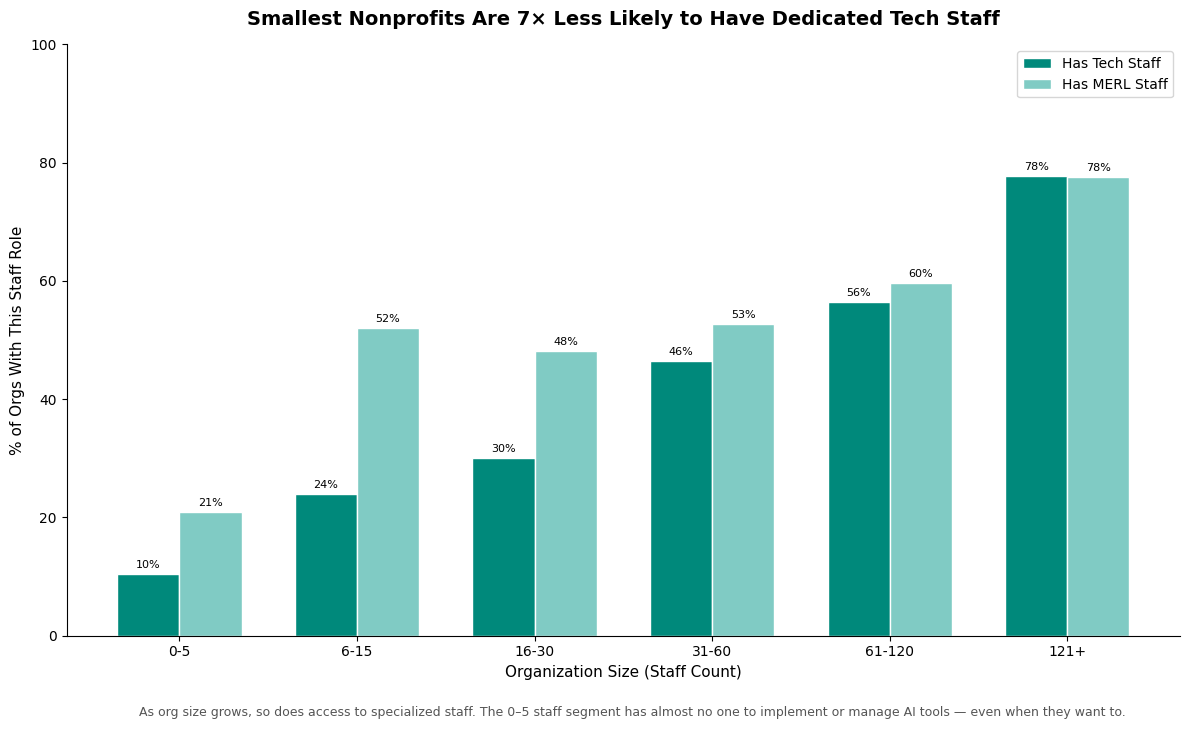

In [33]:
# Chart 1: Smallest Nonprofits Are 7x Less Likely to Have Dedicated Tech Staff
capacity_cols = ['tech_person', 'merl_person']

survey_df['org_size'] = pd.Categorical(survey_df['org_size'], categories=ORG_SIZE_ORDER, ordered=True)
cap_rates = survey_df.groupby('org_size', observed=True)[capacity_cols].mean() * 100

x = np.arange(len(cap_rates))
width = 0.35

fig, ax = pyplot.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, cap_rates['tech_person'], width, label='Has Tech Staff', color='#00897B', edgecolor='white')
bars2 = ax.bar(x + width/2, cap_rates['merl_person'], width, label='Has MERL Staff', color='#80CBC4', edgecolor='white')

ax.set_title("Smallest Nonprofits Are 7× Less Likely to Have Dedicated Tech Staff", fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Organization Size (Staff Count)', fontsize=11)
ax.set_ylabel('% of Orgs With This Staff Role', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(cap_rates.index)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.0f%%', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)
sns.despine()

pyplot.figtext(0.12, -0.03,
    'As org size grows, so does access to specialized staff. The 0–5 staff segment has almost no one to implement or manage AI tools — even when they want to.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

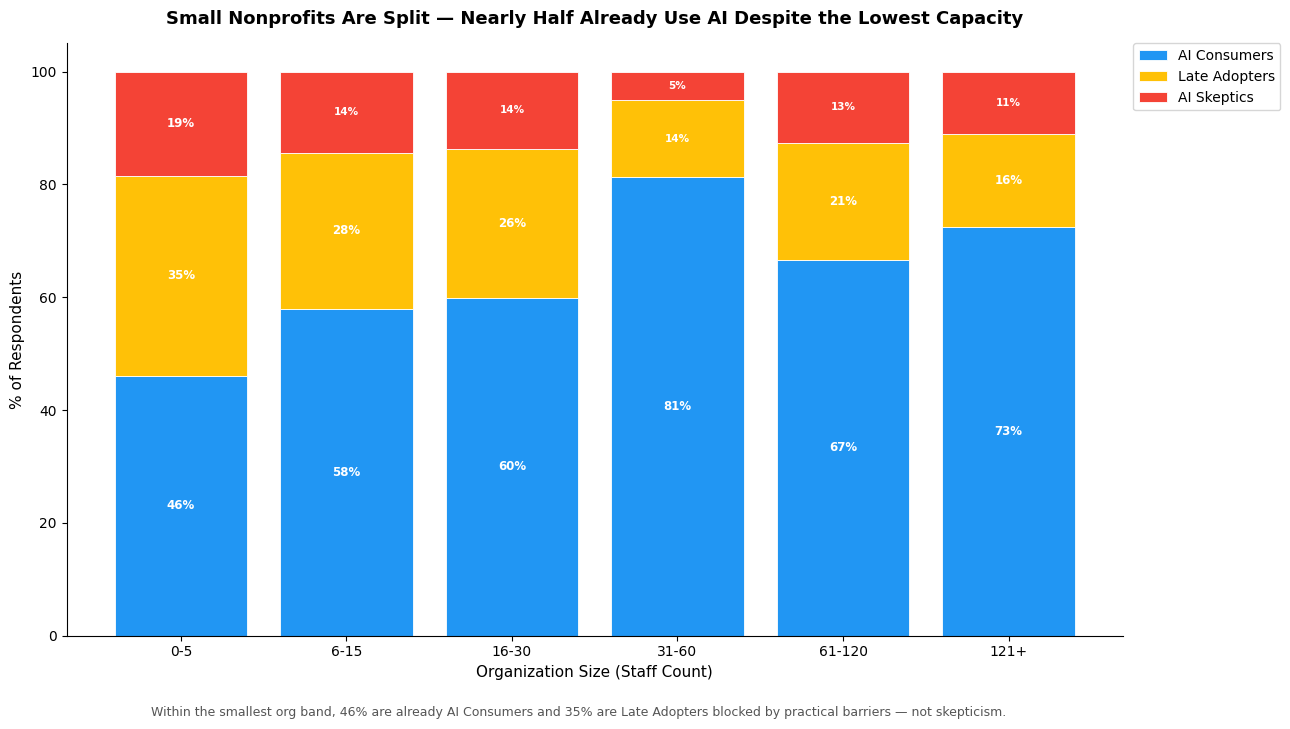

In [ ]:
# Chart 2: Small Nonprofits Are Split — Nearly Half Already Use AI Despite Low Capacity
survey_df['cluster_label'] = survey_df['cluster3'].map(CLUSTER_LABELS)

cluster_size = (
    survey_df.groupby(['org_size', 'cluster_label'], observed=True)
    .size()
    .unstack(fill_value=0)
)
cluster_size_pct = cluster_size.div(cluster_size.sum(axis=1), axis=0) * 100
cluster_order = ['AI Consumers', 'Late Adopters', 'AI Skeptics']
cluster_size_pct = cluster_size_pct[cluster_order]

fig, ax = pyplot.subplots(figsize=(13, 7))
bottom = np.zeros(len(cluster_size_pct))
bar_colors = [CLUSTER_PALETTE[1], CLUSTER_PALETTE[0], CLUSTER_PALETTE[-1]]

for col, color in zip(cluster_order, bar_colors):
    ax.bar(cluster_size_pct.index, cluster_size_pct[col], bottom=bottom, label=col, color=color, edgecolor='white', linewidth=0.6)
    for i, (val, bot) in enumerate(zip(cluster_size_pct[col], bottom)):
        if val > 5:
            fontsize = 8.5 if val > 15 else 7.5
            ax.text(i, bot + val / 2, f'{val:.0f}%', ha='center', va='center', fontsize=fontsize, color='white', fontweight='bold')
    bottom += cluster_size_pct[col].values

ax.set_title("Small Nonprofits Are Split — Nearly Half Already Use AI Despite the Lowest Capacity", fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Organization Size (Staff Count)', fontsize=11)
ax.set_ylabel('% of Respondents', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
sns.despine()

pyplot.figtext(0.12, -0.03,
    'Within the smallest org band, 46% are already AI Consumers and 35% are Late Adopters blocked by practical barriers — not skepticism.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

## Step 2: AI Readiness

**Goal:** Identify which nonprofits are most ready to adopt AI support tools.

- Use `cluster3` as the primary readiness segmentation
- Compare **AI Consumers**, **Late Adopters**, and **Skeptics**
- Summarize AI comfort, current use, and readiness by segment
- Output: cluster summary table + stacked adoption chart

In [ ]:
# --- Cluster Summary Table ---
# Ensure cluster_label column exists on merged_df
if 'cluster_label' not in merged_df.columns:
    merged_df['cluster_label'] = merged_df['cluster3'].map(CLUSTER_LABELS)

# Key AI-use columns from the normalized dataset (binary 0/1)
USE_COLS = [
    '[U] Generat', '[U] Ask', '[U] Organi',
    '[U] Interpret', '[U] Assist', '[U] Translat', '[U] Predict',
]
NICE_NAMES = {
    '[U] Generat':   'Generative AI',
    '[U] Ask':       'Chatbot / Q&A',
    '[U] Organi':    'Organize Data',
    '[U] Interpret': 'Interpret Data',
    '[U] Assist':    'Virtual Assistant',
    '[U] Translat':  'Translate / Transcribe',
    '[U] Predict':   'Predictive AI',
}

cluster_order_r = ['AI Consumers', 'Late Adopters', 'AI Skeptics']

# ai_want_2+ lives in normalized_df; bring it into merged_df if needed
if 'ai_want_2+_norm' not in merged_df.columns:
    if 'ai_want_2+' in normalized_df.columns:
        merged_df['ai_want_2+_norm'] = normalized_df.reindex(merged_df.index)['ai_want_2+']
    else:
        merged_df['ai_want_2+_norm'] = 0  # fallback

# Detect correct USE column names in merged_df (may have _norm suffix)
use_cols_actual = []
for c in USE_COLS:
    if c in merged_df.columns:
        use_cols_actual.append(c)
    elif c + '_norm' in merged_df.columns:
        use_cols_actual.append(c + '_norm')

# Build aggregation
agg_dict = {'person_ai_comfort_raw': 'mean', 'ai_want_2+_norm': 'mean'}
for col in use_cols_actual:
    agg_dict[col] = 'mean'

summary = merged_df.groupby('cluster_label').agg(
    Size=('cluster_label', 'size'),
    **{k: (k, v) for k, v in agg_dict.items()}
).reindex(cluster_order_r)

# Rename columns for presentation
rename_map = {
    'person_ai_comfort_raw': 'Avg AI Comfort (0-10)',
    'ai_want_2+_norm': 'Wants 2+ AI Uses (%)',
}
for orig, nice in NICE_NAMES.items():
    for actual in use_cols_actual:
        if orig in actual:
            rename_map[actual] = f'Uses: {nice} (%)'

summary = summary.rename(columns=rename_map)

# Format percentages
for col in summary.columns:
    if '(%)' in col:
        summary[col] = (summary[col] * 100).round(1)
    elif '(0-10)' in col:
        summary[col] = summary[col].round(1)

summary.index.name = 'Segment'
print('=== AI Readiness: Cluster Summary ===')
summary

=== AI Readiness: Cluster Summary ===


,Size,Avg AI Comfort (0-10),Wants 2+ AI Uses (%),Uses: Generative AI (%),Uses: Chatbot / Q&A (%),Uses: Organize Data (%),Uses: Interpret Data (%),Uses: Virtual Assistant (%),Uses: Translate / Transcribe (%),Uses: Predictive AI (%)
Segment,,,,,,,,,,
AI Consumers,514,7.6,90.5,84.4,51.0,28.0,23.0,24.9,37.5,16.0
Late Adopters,254,4.8,54.3,3.1,2.8,1.2,0.8,0.0,2.8,2.0
AI Skeptics,138,5.7,46.4,37.0,20.3,15.2,10.1,10.9,14.5,8.0


### Stacked AI Use-Case Adoption by Readiness Segment

This chart shows how different types of current AI usage are distributed across the three readiness segments. 
It reveals that AI Consumers layer multiple tools simultaneously, while Late Adopters and Skeptics concentrate on fewer, simpler use-cases.

### Stacked AI Use-Case Adoption by Readiness Segment

This chart shows how different types of current AI usage are distributed across the three readiness segments. 
It reveals that AI Consumers layer multiple tools simultaneously, while Late Adopters and Skeptics concentrate on fewer, simpler use-cases.

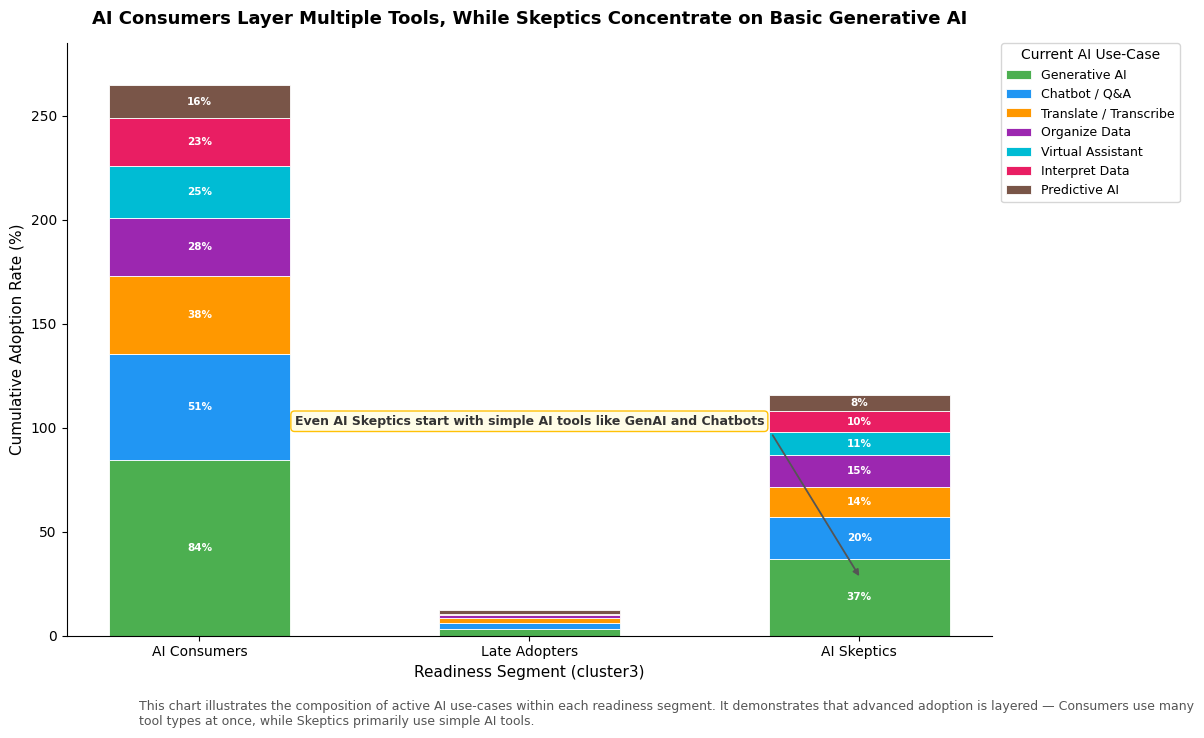

In [ ]:
# --- Stacked Adoption Chart: Current AI Use-Cases by Cluster ---

# Compute adoption rates per cluster for each use-case
adoption = merged_df.groupby('cluster_label')[use_cols_actual].mean().reindex(cluster_order_r) * 100

# Rename columns for readability
col_rename = {}
for orig, nice in NICE_NAMES.items():
    for actual in use_cols_actual:
        if orig in actual:
            col_rename[actual] = nice
adoption = adoption.rename(columns=col_rename)

# Sort use-cases by overall popularity (descending) for visual clarity
col_order = adoption.mean().sort_values(ascending=False).index.tolist()
adoption = adoption[col_order]

# Color palette for the AI use-case categories
USE_CASE_PALETTE = [
    '#4CAF50',   # green
    '#2196F3',   # blue
    '#FF9800',   # orange
    '#9C27B0',   # purple
    '#00BCD4',   # cyan
    '#E91E63',   # pink
    '#795548',   # brown
]

fig, ax = pyplot.subplots(figsize=(12, 7))

x = np.arange(len(cluster_order_r))
bottom = np.zeros(len(cluster_order_r))

bars_list = []
for idx, col in enumerate(adoption.columns):
    color = USE_CASE_PALETTE[idx % len(USE_CASE_PALETTE)]
    bars = ax.bar(x, adoption[col].values, bottom=bottom, label=col,
                  color=color, edgecolor='white', linewidth=0.6, width=0.55)
    # Label each segment inside the bar if large enough
    for i, (val, bot) in enumerate(zip(adoption[col].values, bottom)):
        if val > 6:
            ax.text(x[i], bot + val / 2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold')
    bottom += adoption[col].values
    bars_list.append(bars)

# --- Annotation callout: above Late Adopters, pointing to Skeptics (GenAI + Chatbot) ---
late_x = cluster_order_r.index('Late Adopters')
skeptics_x = cluster_order_r.index('AI Skeptics')

late_total = float(adoption.loc['Late Adopters'].sum())

target_cols = [c for c in ['Generative AI', 'Chatbot / Q&A'] if c in adoption.columns]
bottom = 0.0
min_y = None
max_y = None
for c in adoption.columns:
    v = float(adoption.loc['AI Skeptics', c])
    if c in target_cols:
        if min_y is None:
            min_y = bottom
        max_y = bottom + v
    bottom += v

skeptics_y = ((min_y + max_y) / 2) if (min_y is not None and max_y is not None) else float(adoption.loc['AI Skeptics'].sum()) / 2

ax.annotate(
    'Even AI Skeptics start with simple AI tools like GenAI and Chatbots',
    xy=(skeptics_x, skeptics_y),                 # arrowhead lands inside Skeptics GenAI+Chatbot stack
    xycoords='data',
    xytext=(late_x, 100),             # centered above Late Adopters, slightly above bar top
    textcoords='data',
    ha='center', va='bottom',
    annotation_clip=False,
    fontsize=9, fontweight='bold', color='#333',
    arrowprops=dict(
        arrowstyle='-|>',
        color='#555',
        lw=1.3,
        relpos=(1.0, 0.5),                       # tail starts at right side of the annotation box
        shrinkA=6,
        shrinkB=0                                # keep arrowhead touching the bar (no gap)
    ),
    bbox=dict(boxstyle='round,pad=0.3', fc='#FFFDE7', ec='#FFC107', lw=1),
)

# Ensure the above-bar label isn’t clipped
ax.set_ylim(0, max(float(adoption.sum(axis=1).max()), late_total) + 20)


ax.set_title(
    'AI Consumers Layer Multiple Tools, While Skeptics Concentrate on Basic Generative AI',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Readiness Segment (cluster3)', fontsize=11)
ax.set_ylabel('Cumulative Adoption Rate (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(cluster_order_r, fontsize=10)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,
          title='Current AI Use-Case', title_fontsize=10)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'This chart illustrates the composition of active AI use-cases within each readiness segment. '
    'It demonstrates that advanced adoption is layered \u2014 Consumers use many tool types at once, while Skeptics primarily use simple AI tools.',
    fontsize=9, color='#555', wrap=True
)

pyplot.tight_layout()
pyplot.show()